In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

df = pd.read_csv('../data/processed/loan_cleaned.csv')
print("Shape:", df.shape)
print("Loaded successfully!")

Shape: (307511, 75)
Loaded successfully!


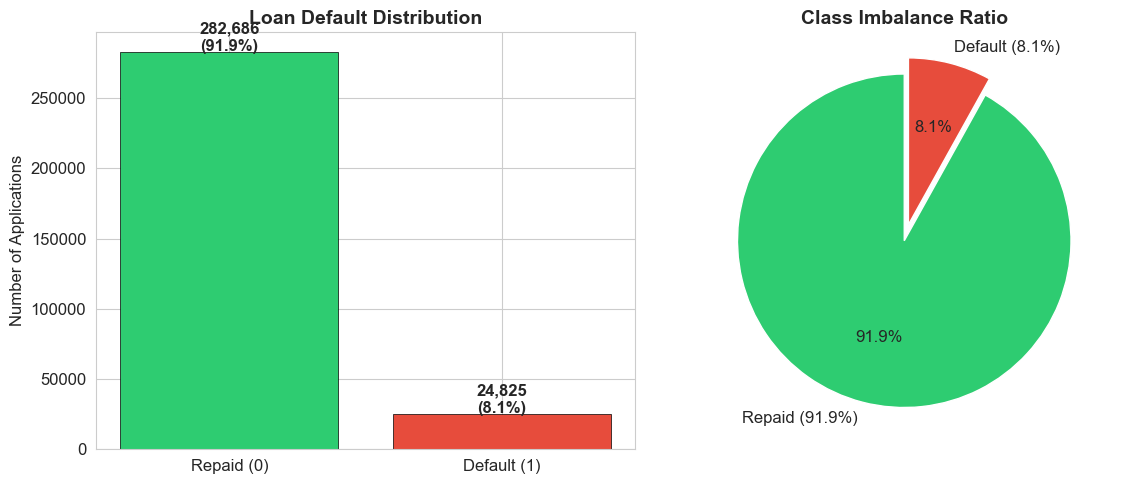

Insight: 8.07% default rate — severe class imbalance. SMOTE will be required.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df['TARGET'].value_counts()
axes[0].bar(['Repaid (0)', 'Default (1)'], 
            counts.values, 
            color=['#2ecc71', '#e74c3c'],
            edgecolor='black', linewidth=0.5)
axes[0].set_title('Loan Default Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Applications')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)', 
                ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, 
            labels=['Repaid (91.9%)', 'Default (8.1%)'],
            colors=['#2ecc71', '#e74c3c'],
            explode=(0, 0.1),
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Class Imbalance Ratio', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: 8.07% default rate — severe class imbalance. SMOTE will be required.")

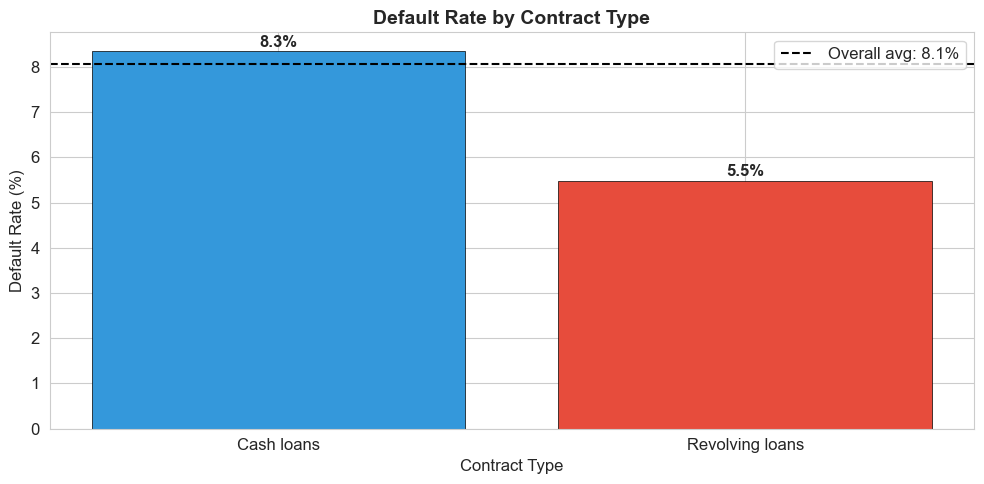

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

contract_default = df.groupby('NAME_CONTRACT_TYPE')['TARGET'].mean() * 100

bars = ax.bar(contract_default.index, 
              contract_default.values,
              color=['#3498db', '#e74c3c'],
              edgecolor='black', linewidth=0.5)

ax.set_title('Default Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Default Rate (%)')
ax.set_xlabel('Contract Type')
ax.axhline(y=df['TARGET'].mean()*100, color='black', 
           linestyle='--', linewidth=1.5, label=f'Overall avg: {df["TARGET"].mean()*100:.1f}%')
ax.legend()

for bar, val in zip(bars, contract_default.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/02_default_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

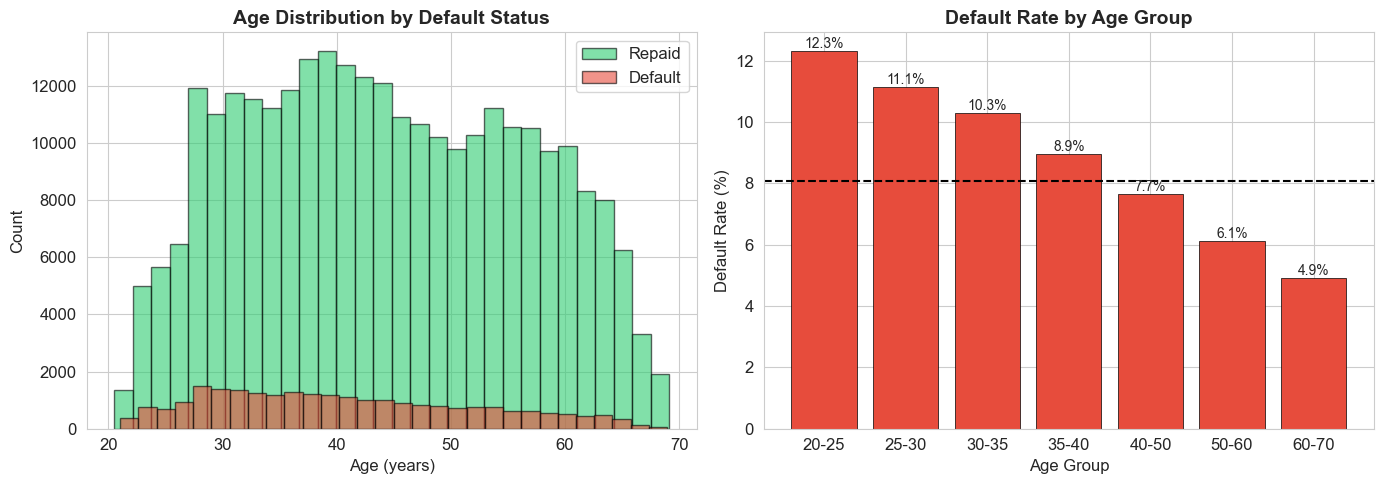

Insight: Younger applicants (20-30) default more — age is a strong predictor.


In [4]:
# Convert DAYS_BIRTH to age in years
df['AGE_YEARS'] = df['DAYS_BIRTH'] / 365

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by default status
for target, label, color in [(0, 'Repaid', '#2ecc71'), (1, 'Default', '#e74c3c')]:
    axes[0].hist(df[df['TARGET']==target]['AGE_YEARS'], 
                bins=30, alpha=0.6, label=label, color=color, edgecolor='black')
axes[0].set_title('Age Distribution by Default Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Default rate by age group
df['AGE_GROUP'] = pd.cut(df['AGE_YEARS'], 
                          bins=[20, 25, 30, 35, 40, 50, 60, 70],
                          labels=['20-25','25-30','30-35','35-40','40-50','50-60','60-70'])
age_default = df.groupby('AGE_GROUP', observed=True)['TARGET'].mean() * 100
axes[1].bar(age_default.index, age_default.values, 
            color='#e74c3c', edgecolor='black', linewidth=0.5)
axes[1].set_title('Default Rate by Age Group', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Default Rate (%)')
axes[1].axhline(y=df['TARGET'].mean()*100, color='black', 
                linestyle='--', linewidth=1.5)

for i, (idx, val) in enumerate(age_default.items()):
    axes[1].text(i, val + 0.1, f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/03_age_vs_default.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Younger applicants (20-30) default more — age is a strong predictor.")

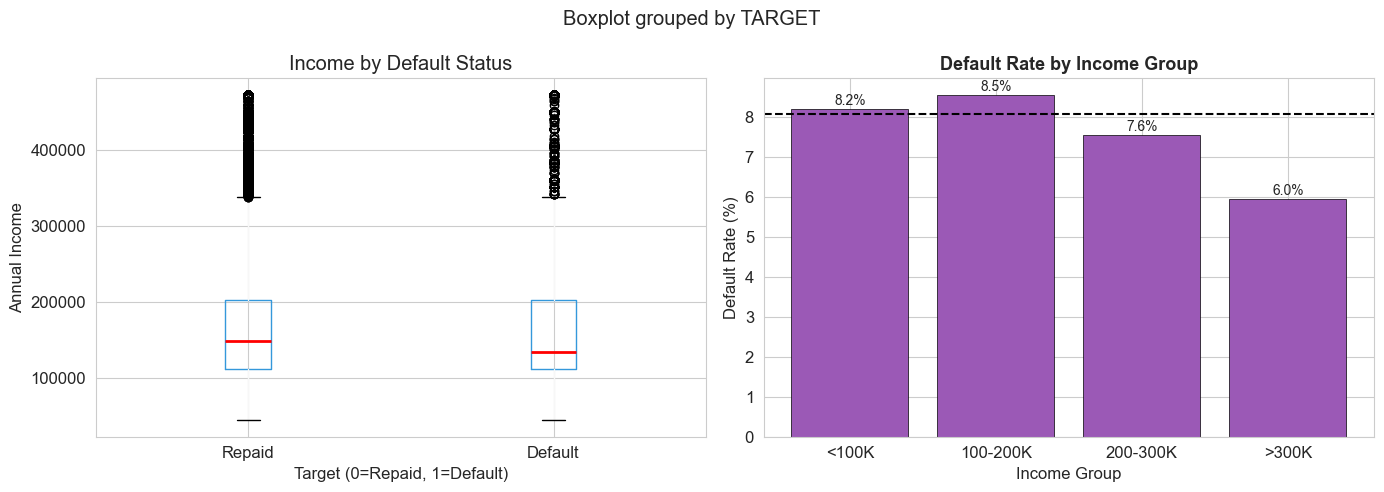

Insight: Lower income applicants default more frequently.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df.boxplot(column='AMT_INCOME_TOTAL', by='TARGET', ax=axes[0],
           boxprops=dict(color='#3498db'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Income Distribution by Default Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Target (0=Repaid, 1=Default)')
axes[0].set_ylabel('Annual Income')
axes[0].set_xticklabels(['Repaid', 'Default'])
plt.sca(axes[0])
plt.title('Income by Default Status')

# Income groups
df['INCOME_GROUP'] = pd.cut(df['AMT_INCOME_TOTAL'],
                             bins=[0, 100000, 200000, 300000, 500000],
                             labels=['<100K', '100-200K', '200-300K', '>300K'])
income_default = df.groupby('INCOME_GROUP', observed=True)['TARGET'].mean() * 100
axes[1].bar(income_default.index, income_default.values,
            color='#9b59b6', edgecolor='black', linewidth=0.5)
axes[1].set_title('Default Rate by Income Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Income Group')
axes[1].set_ylabel('Default Rate (%)')
axes[1].axhline(y=df['TARGET'].mean()*100, color='black',
                linestyle='--', linewidth=1.5)
for i, (idx, val) in enumerate(income_default.items()):
    axes[1].text(i, val + 0.1, f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/04_income_vs_default.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Lower income applicants default more frequently.")

EXT_SOURCE_1 — Repaid mean: 0.508 | Default mean: 0.458
EXT_SOURCE_2 — Repaid mean: 0.524 | Default mean: 0.411
EXT_SOURCE_3 — Repaid mean: 0.524 | Default mean: 0.424


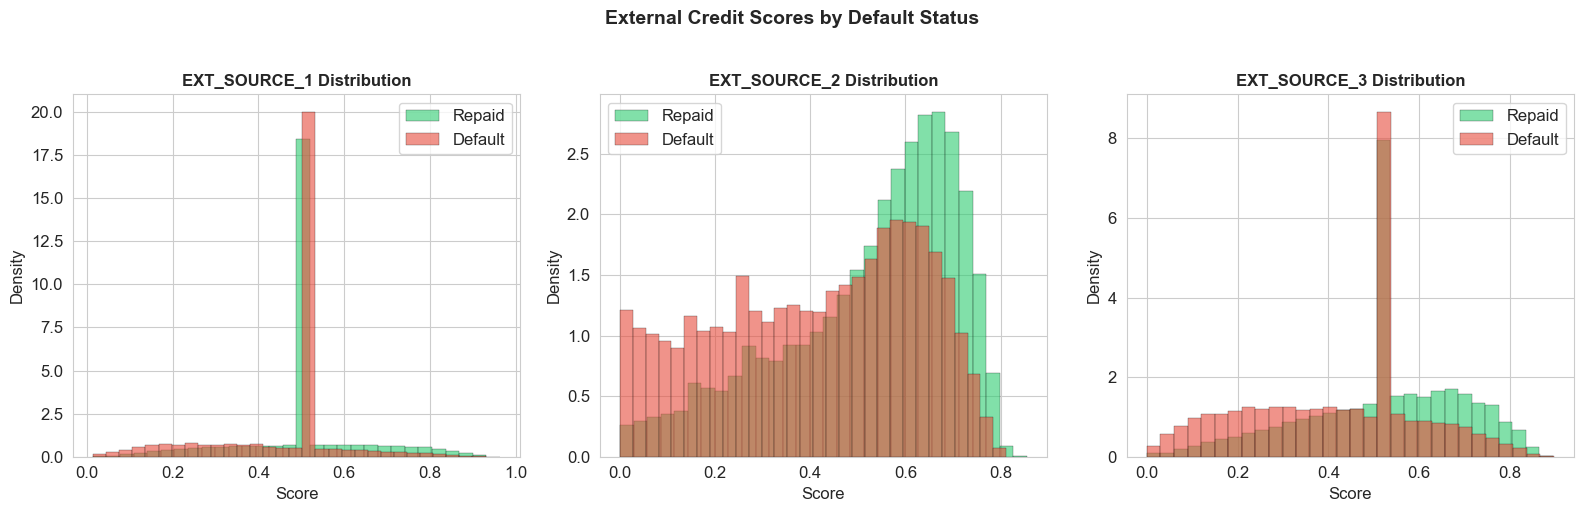


Insight: Lower EXT_SOURCE scores strongly correlate with default — top predictors.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    for target, label, color in [(0, 'Repaid', '#2ecc71'), (1, 'Default', '#e74c3c')]:
        axes[i].hist(df[df['TARGET']==target][col].dropna(),
                    bins=30, alpha=0.6, label=label, 
                    color=color, edgecolor='black', linewidth=0.3,
                    density=True)
    axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Density')
    axes[i].legend()

    # Print mean difference
    mean_repaid  = df[df['TARGET']==0][col].mean()
    mean_default = df[df['TARGET']==1][col].mean()
    print(f"{col} — Repaid mean: {mean_repaid:.3f} | Default mean: {mean_default:.3f}")

plt.suptitle('External Credit Scores by Default Status', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/05_ext_sources_vs_default.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nInsight: Lower EXT_SOURCE scores strongly correlate with default — top predictors.")

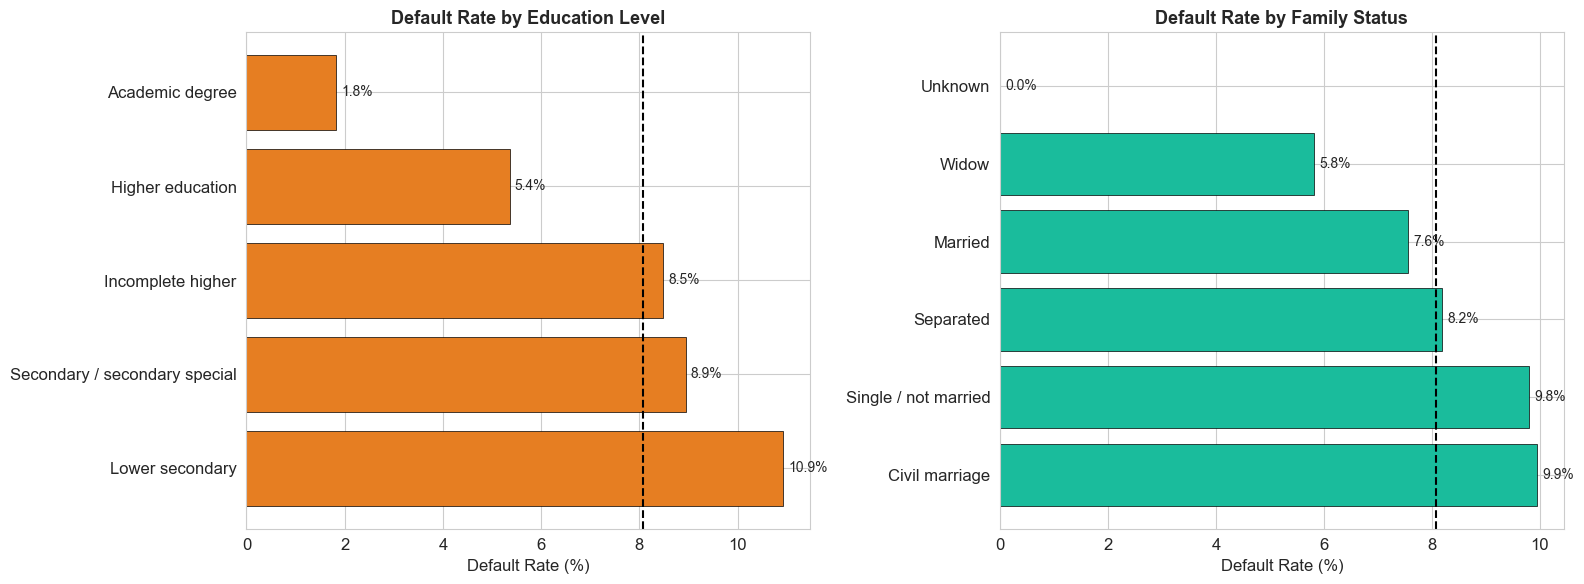

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Education
edu_default = df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values(ascending=False) * 100
axes[0].barh(edu_default.index, edu_default.values, 
             color='#e67e22', edgecolor='black', linewidth=0.5)
axes[0].set_title('Default Rate by Education Level', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Default Rate (%)')
axes[0].axvline(x=df['TARGET'].mean()*100, color='black', 
                linestyle='--', linewidth=1.5)
for i, val in enumerate(edu_default.values):
    axes[0].text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=10)

# Family status
fam_default = df.groupby('NAME_FAMILY_STATUS')['TARGET'].mean().sort_values(ascending=False) * 100
axes[1].barh(fam_default.index, fam_default.values,
             color='#1abc9c', edgecolor='black', linewidth=0.5)
axes[1].set_title('Default Rate by Family Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Default Rate (%)')
axes[1].axvline(x=df['TARGET'].mean()*100, color='black',
                linestyle='--', linewidth=1.5)
for i, val in enumerate(fam_default.values):
    axes[1].text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/06_education_family_default.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Select key numeric features for correlation
key_features = [
    'TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'DAYS_BIRTH', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'DAYS_EMPLOYED', 'AMT_GOODS_PRICE', 'DAYS_REGISTRATION',
    'OWN_CAR_AGE', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS'
]

corr_matrix = df[key_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            ax=ax,
            linewidths=0.5)
ax.set_title('Correlation Heatmap — Key Features vs Target', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with TARGET
print("=== TOP CORRELATIONS WITH TARGET ===")
target_corr = corr_matrix['TARGET'].drop('TARGET').sort_values()
print(target_corr.to_string())

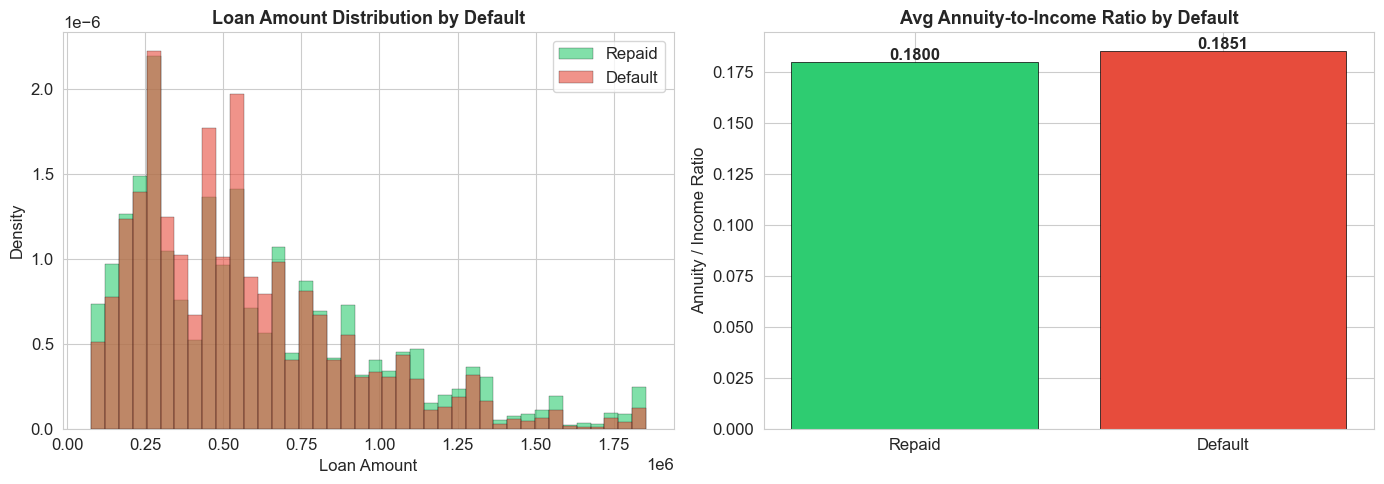

Insight: Higher annuity-to-income ratio = higher financial burden = more defaults.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Credit amount distribution
for target, label, color in [(0, 'Repaid', '#2ecc71'), (1, 'Default', '#e74c3c')]:
    axes[0].hist(df[df['TARGET']==target]['AMT_CREDIT'],
                bins=40, alpha=0.6, label=label,
                color=color, edgecolor='black', linewidth=0.3,
                density=True)
axes[0].set_title('Loan Amount Distribution by Default', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Loan Amount')
axes[0].set_ylabel('Density')
axes[0].legend()

# Annuity to income ratio
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
ratio_default = df.groupby('TARGET')['ANNUITY_INCOME_RATIO'].mean()
axes[1].bar(['Repaid', 'Default'], ratio_default.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Avg Annuity-to-Income Ratio by Default', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Annuity / Income Ratio')
for i, val in enumerate(ratio_default.values):
    axes[1].text(i, val + 0.001, f'{val:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/08_loan_amounts_default.png', dpi=150, bbox_inches='tight')
plt.show()
print("Insight: Higher annuity-to-income ratio = higher financial burden = more defaults.")


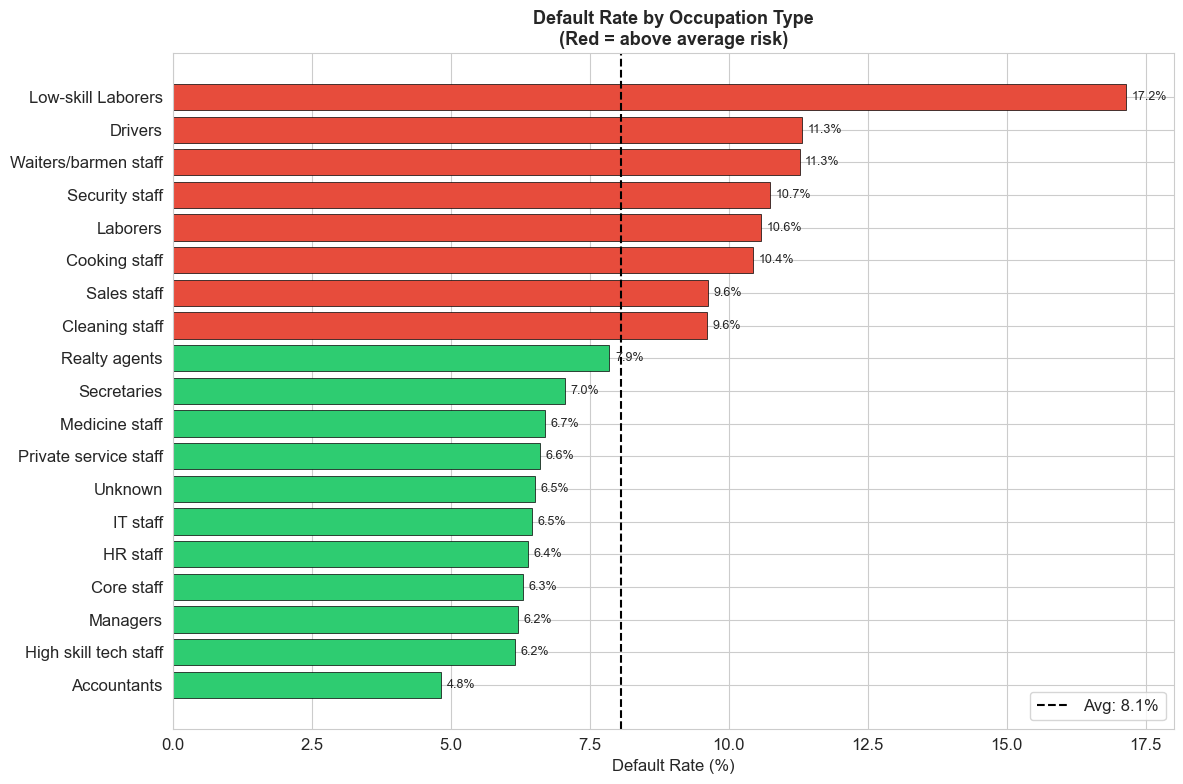

In [10]:
fig, ax = plt.subplots(figsize=(12, 8))

occ_default = df.groupby('OCCUPATION_TYPE')['TARGET'].mean().sort_values(ascending=True) * 100
colors = ['#e74c3c' if v > df['TARGET'].mean()*100 else '#2ecc71' 
          for v in occ_default.values]

ax.barh(occ_default.index, occ_default.values, 
        color=colors, edgecolor='black', linewidth=0.5)
ax.set_title('Default Rate by Occupation Type\n(Red = above average risk)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Default Rate (%)')
ax.axvline(x=df['TARGET'].mean()*100, color='black',
           linestyle='--', linewidth=1.5, label=f'Avg: {df["TARGET"].mean()*100:.1f}%')
ax.legend()
for i, val in enumerate(occ_default.values):
    ax.text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/09_occupation_default.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print("=" * 60)
print("EDA SUMMARY — KEY INSIGHTS FOR MODELING")
print("=" * 60)

print(f"""
1. CLASS IMBALANCE
   Default rate: {df['TARGET'].mean()*100:.1f}%
   Ratio: ~12:1 (repaid:default)
   Action: Use SMOTE + class_weight='balanced'

2. TOP PREDICTIVE FEATURES (from correlation)
   EXT_SOURCE_1/2/3 — strongest negative correlation with default
   DAYS_BIRTH (age) — older = less likely to default
   DAYS_EMPLOYED — longer employment = less likely to default

3. HIGH RISK SEGMENTS
   Age: 20-30 year olds default most
   Education: Lower secondary education highest default rate
   Occupation: Check plot 9 for high-risk occupations

4. FEATURE ENGINEERING OPPORTUNITIES (for Step 4)
   - ANNUITY_INCOME_RATIO (already created)
   - AGE_YEARS from DAYS_BIRTH (already created)
   - CREDIT_INCOME_RATIO = AMT_CREDIT / AMT_INCOME_TOTAL
   - EMPLOYED_YEARS = DAYS_EMPLOYED / 365

5. MULTICOLLINEARITY TO WATCH
   AMT_CREDIT and AMT_GOODS_PRICE are highly correlated
   CNT_CHILDREN and CNT_FAM_MEMBERS are highly correlated
""")

EDA SUMMARY — KEY INSIGHTS FOR MODELING

1. CLASS IMBALANCE
   Default rate: 8.1%
   Ratio: ~12:1 (repaid:default)
   Action: Use SMOTE + class_weight='balanced'

2. TOP PREDICTIVE FEATURES (from correlation)
   EXT_SOURCE_1/2/3 — strongest negative correlation with default
   DAYS_BIRTH (age) — older = less likely to default
   DAYS_EMPLOYED — longer employment = less likely to default

3. HIGH RISK SEGMENTS
   Age: 20-30 year olds default most
   Education: Lower secondary education highest default rate
   Occupation: Check plot 9 for high-risk occupations

4. FEATURE ENGINEERING OPPORTUNITIES (for Step 4)
   - ANNUITY_INCOME_RATIO (already created)
   - AGE_YEARS from DAYS_BIRTH (already created)
   - CREDIT_INCOME_RATIO = AMT_CREDIT / AMT_INCOME_TOTAL
   - EMPLOYED_YEARS = DAYS_EMPLOYED / 365

5. MULTICOLLINEARITY TO WATCH
   AMT_CREDIT and AMT_GOODS_PRICE are highly correlated
   CNT_CHILDREN and CNT_FAM_MEMBERS are highly correlated



In [12]:
# Drop temporary EDA columns before saving
# (we'll recreate them properly in feature engineering)
df.drop(columns=['AGE_YEARS', 'AGE_GROUP', 
                 'INCOME_GROUP', 'ANNUITY_INCOME_RATIO'], 
        inplace=True)

df.to_csv('../data/processed/loan_cleaned.csv', index=False)
print("Saved updated file.")
print("All 10 EDA plots saved to reports/figures/")

Saved updated file.
All 10 EDA plots saved to reports/figures/
